# 🎵 The Cultural Misery Index

**Multimodal Semantic Audio Clustering × Macroeconomic Shock Correlation × GenAI Narrative Engine**

> *Does music reveal the collective psyche of a nation under economic stress?*

This notebook fuses three data streams — **Spotify streaming trends**, **Genius lyric
semantics**, and **FRED macroeconomic indicators** — to track how American music tastes
shift in response to economic pressure.

Instead of static genres, we cluster songs purely on their auditory "vibe" and lyrical
themes, then measure whether clusters like "High-Energy Melancholic Pop" expand during
inflation spikes or unemployment surges.

---

## Pipeline Overview

```
[FRED API: Misery Index] ───┐
                            ▼
[Kaggle: Audio Features] ──► [Feature Fusion] ──► [Temporal Clustering] ──► [Econometric Mapping] ──► [GenAI Narrator]
[Genius API: Lyrics]     ──►  (UMAP/PCA)           (Hungarian Algo)          (Rolling Correlation)      (Gemini 3.5 Flash)
```

---
## 0. Setup & Configuration

In [1]:
# Core imports
import logging
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from IPython.display import display, Markdown

# Suppress noisy warnings for cleaner notebook output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="umap")

# Logging — set to INFO so we see pipeline progress
logging.basicConfig(level=logging.INFO, format="%(name)s | %(message)s")

# Matplotlib / Seaborn style
sns.set_theme(style="darkgrid", palette="viridis", font_scale=1.1)
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 100

print("✅ Core imports loaded")

✅ Core imports loaded


In [2]:
# CMI pipeline imports
from cmi.config import (
    AUDIO_FEATURES, DATA_RAW, DATA_PROCESSED, K_CLUSTERS,
    REGION, DATE_START, DATE_END, EMBEDDING_DIM_TARGET,
)
from cmi.ingest.spotify_charts import load_charts, get_unique_tracks
from cmi.ingest.genius_lyrics import fetch_lyrics_batch
from cmi.ingest.fred_macro import fetch_misery_index
from cmi.features.audio import extract_audio_matrix, scale_audio, audio_feature_summary
from cmi.features.embeddings import embed_lyrics
from cmi.features.fusion import reduce_embeddings, fuse_features
from cmi.clustering.temporal import cluster_temporal_windows, ClusterTimeline
from cmi.clustering.diagnostics import elbow_plot, silhouette_analysis, cluster_stability_score
from cmi.correlation.econometrics import (
    compute_volumetric_shares, rolling_correlation,
    static_correlation, granger_causality, classify_clusters,
)
from cmi.narrative.engine import build_cluster_payload, generate_narrative, generate_full_report

print("✅ CMI pipeline modules loaded")
print(f"   Region: {REGION}")
print(f"   Date range: {DATE_START} → {DATE_END}")
print(f"   Cluster count (K): {K_CLUSTERS}")
print(f"   Audio features: {AUDIO_FEATURES}")

✅ CMI pipeline modules loaded
   Region: us
   Date range: 2018-01-01 → 2024-12-31
   Cluster count (K): 6
   Audio features: ['danceability', 'energy', 'valence', 'acousticness', 'tempo', 'speechiness', 'instrumentalness']


---
## 1. Data Ingestion

We pull from three independent data sources, all joined on a temporal axis
(monthly intervals, 2018–2024):

1. **Spotify Charts** (Kaggle) — weekly Top 200 tracks with audio features
2. **Genius** — full lyric sheets for semantic analysis
3. **FRED** — unemployment + CPI → Okun's Misery Index

### 1.1 Spotify Chart Data (Kaggle)

Since Spotify restricted their audio features API for new apps in November 2024,
we use a pre-compiled Kaggle dataset that was built before the lockdown.

> **First time?** Run `uv run python scripts/download_kaggle_data.py` to download the data,
> or manually place a Spotify charts CSV in `data/raw/`.

In [3]:
# Find the chart CSV in data/raw/
csv_files = list(DATA_RAW.glob("*.csv"))
print(f"📂 Found {len(csv_files)} CSV files in {DATA_RAW}:")
for f in csv_files:
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"   {f.name} ({size_mb:.1f} MB)")

📂 Found 2 CSV files in /Users/sam/Locals Only/Music and Behavioral Embeddings/data/raw:
   Hot Stuff.csv (46.3 MB)
   Hot 100 Audio Features.csv (10.3 MB)


In [4]:
# Load the chart data — update the filename if your CSV is named differently
# The loader handles various Kaggle column name conventions automatically
CHART_CSV = DATA_RAW / "charts.csv"  # ← Adjust this filename to match your download

charts_df = load_charts(CHART_CSV, region=REGION, date_start=DATE_START, date_end=DATE_END)
print(f"\n📊 Chart data loaded: {charts_df.shape}")
display(charts_df.head(10))

cmi.ingest.spotify_charts | Loading Billboard charts from /Users/sam/Locals Only/Music and Behavioral Embeddings/data/raw/Hot Stuff.csv
cmi.ingest.spotify_charts | Loading audio features from /Users/sam/Locals Only/Music and Behavioral Embeddings/data/raw/Hot 100 Audio Features.csv
cmi.ingest.spotify_charts | Merging charts with audio features...
cmi.ingest.spotify_charts | Merged shape: (327817, 33)
cmi.ingest.spotify_charts | Date-filtered to 2018-01-01 – 2024-12-31: 17747 rows
cmi.ingest.spotify_charts | Deduplicated: 17747 → 17744 rows
cmi.ingest.spotify_charts | Final chart data shape: (17744, 37)



📊 Chart data loaded: (17744, 37)


,index_x,url,date,rank,title,artist,SongID,Instance,Previous Week Position,Peak Position,...,instrumentalness,liveness,valence,tempo,time_signature,spotify_track_popularity,track_id,region,streams,year_month
0,300674,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,1,Perfect,Ed Sheeran,PerfectEd Sheeran,2,1.0,1,...,0.000000,0.1060,0.168,95.050,3.0,88.0,0tgVpDi06FyKpA1z0VMD4v,us,0,2018-01
1,194901,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,2,Rockstar,Post Malone Featuring 21 Savage,RockstarPost Malone Featuring 21 Savage,1,2.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,RockstarPost Malone Featuring 21 Savage,us,0,2018-01
2,283331,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,3,Havana,Camila Cabello Featuring Young Thug,HavanaCamila Cabello Featuring Young Thug,2,3.0,2,...,0.000036,0.1320,0.394,104.988,4.0,86.0,1rfofaqEpACxVEHIZBJe6W,us,0,2018-01
3,311418,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,4,No Limit,G-Eazy Featuring A$AP Rocky & Cardi B,No LimitG-Eazy Featuring A$AP Rocky & Cardi B,1,5.0,4,...,0.000000,0.0853,0.405,175.957,4.0,78.0,2DQ1ITjI0YoLFzuADN1ZBW,us,0,2018-01
4,86090,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,5,Thunder,Imagine Dragons,ThunderImagine Dragons,1,6.0,4,...,0.134000,0.1470,0.288,167.997,4.0,87.0,1zB4vmk8tFRmM9UULNzbLB,us,0,2018-01
5,311511,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,6,Gucci Gang,Lil Pump,Gucci GangLil Pump,1,4.0,3,...,0.000000,0.1170,0.699,119.889,4.0,76.0,43ZyHQITOjhciSUUNPVRHc,us,0,2018-01
6,212271,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,7,MotorSport,"Migos, Nicki Minaj & Cardi B","MotorSportMigos, Nicki Minaj & Cardi B",1,7.0,6,...,0.000000,0.3170,0.174,138.016,4.0,77.0,4wFjTWCunQFKtukqrNijEt,us,0,2018-01
7,123450,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,8,Too Good At Goodbyes,Sam Smith,Too Good At GoodbyesSam Smith,1,8.0,4,...,0.000000,0.1770,0.523,91.500,4.0,78.0,3VlbOrM6nYPprVvzBZllE5,us,0,2018-01
8,262808,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,9,Bad At Love,Halsey,Bad At LoveHalsey,1,10.0,8,...,0.000000,0.0893,0.612,118.384,4.0,79.0,7y9iMe8SOB6z3NoHE2OfXl,us,0,2018-01
9,273270,https://www.billboard.com/charts/hot-100/2018-...,2018-01-06,10,Bodak Yellow (Money Moves),Cardi B,Bodak Yellow (Money Moves)Cardi B,1,12.0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,Bodak Yellow (Money Moves)Cardi B,us,0,2018-01


In [5]:
# Quick data quality check
print("Column dtypes:")
print(charts_df.dtypes)
print(f"\nDate range: {charts_df['date'].min()} → {charts_df['date'].max()}")
print(f"Unique tracks: {charts_df['title'].nunique() if 'title' in charts_df.columns else 'N/A'}")
print(f"Unique months: {charts_df['year_month'].nunique() if 'year_month' in charts_df.columns else 'N/A'}")

# Audio feature coverage
for feat in AUDIO_FEATURES:
    if feat in charts_df.columns:
        null_pct = charts_df[feat].isna().mean() * 100
        print(f"   {feat}: {null_pct:.1f}% null")

Column dtypes:
index_x                               int64
url                                     str
date                         datetime64[us]
rank                                  int64
title                                   str
artist                                  str
SongID                                  str
Instance                              int64
Previous Week Position              float64
Peak Position                         int64
Weeks on Chart                        int64
index_y                               int64
Performer_y                             str
Song_y                                  str
spotify_genre                           str
spotify_track_id                        str
spotify_track_preview_url               str
spotify_track_duration_ms           float64
spotify_track_explicit               object
spotify_track_album                     str
danceability                        float64
energy                              float64
key              

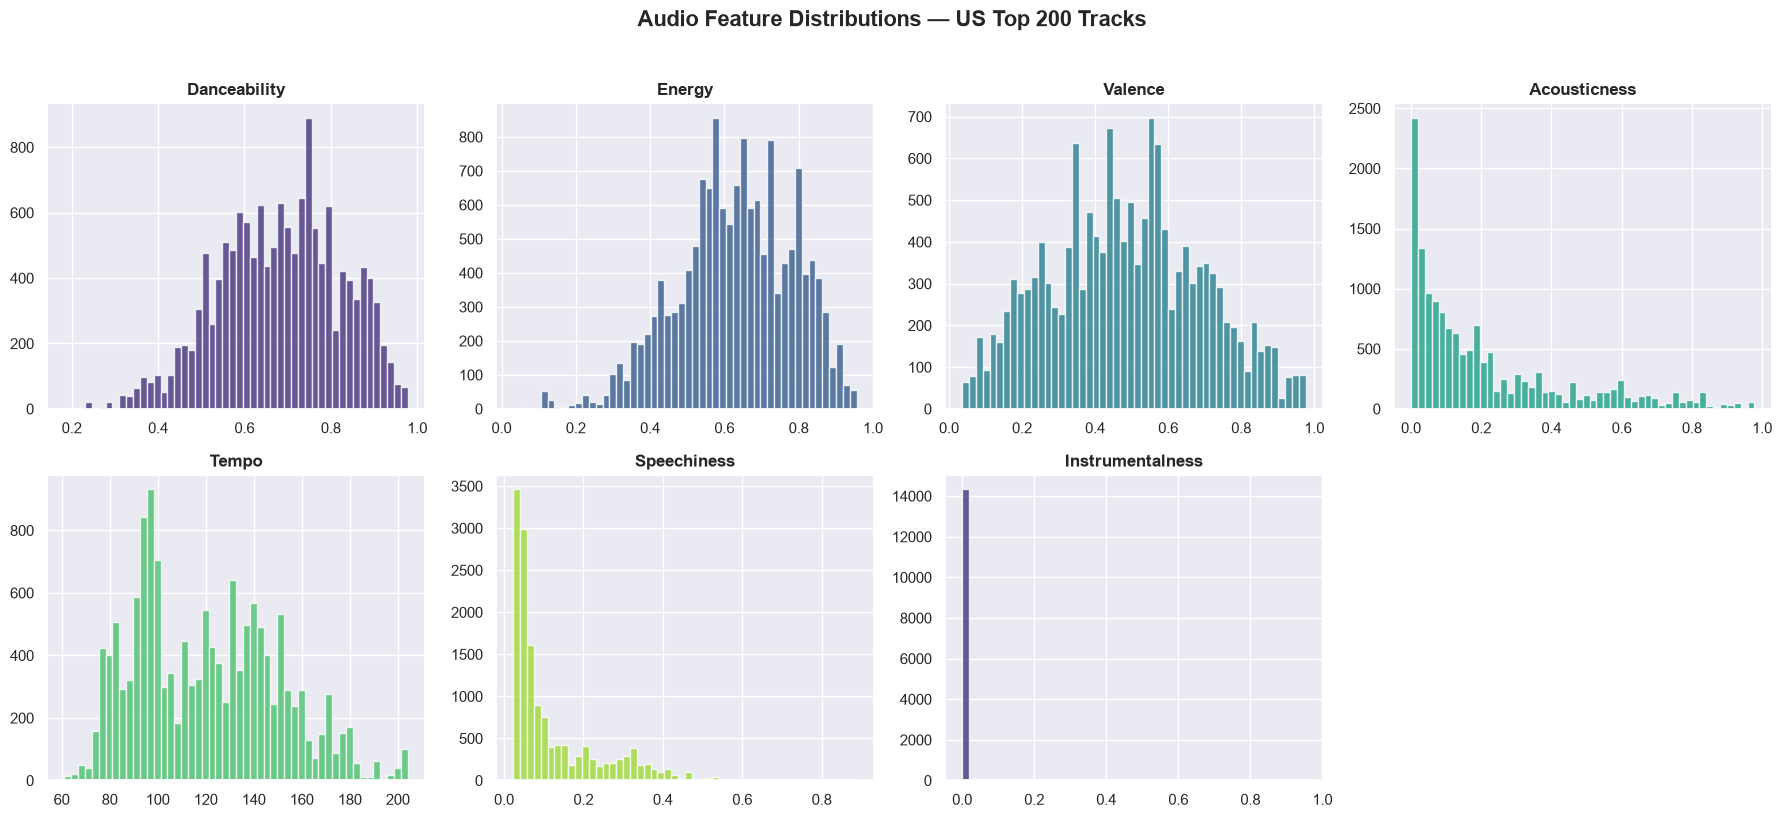

In [6]:
# Audio feature distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
available_feats = [f for f in AUDIO_FEATURES if f in charts_df.columns]

for i, feat in enumerate(available_feats):
    ax = axes.flat[i]
    charts_df[feat].dropna().hist(bins=50, ax=ax, color=sns.color_palette("viridis")[i % 6], alpha=0.8)
    ax.set_title(feat.title(), fontweight="bold")
    ax.set_xlabel("")

# Hide unused subplots
for j in range(len(available_feats), len(axes.flat)):
    axes.flat[j].set_visible(False)

plt.suptitle("Audio Feature Distributions — US Top 200 Tracks", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 1.2 FRED Macroeconomic Data — The Misery Index

Arthur Okun's **Misery Index** = Unemployment Rate + Year-over-Year Inflation.
When it spikes, people are hurting. We use this as our measure of economic stress.

> **Key events in our window:**
> - 2020 Q1–Q2: COVID-19 shock (unemployment spike to 14.7%)
> - 2021–2022: Post-COVID inflation surge
> - 2022 H2: Fed rate hikes, inflation cooling

In [7]:
# Fetch economic data from FRED
misery_df = fetch_misery_index()
print(f"📈 Misery Index: {len(misery_df)} monthly observations")
display(misery_df.head(10))

cmi.ingest.fred_macro | Fetching UNRATE from FRED (2018-01-01 to 2024-12-31)...
cmi.ingest.fred_macro | Fetching CPIAUCSL from FRED (2018-01-01 to 2024-12-31)...
cmi.ingest.fred_macro | Misery Index computed: 72 months, range 5.2 – 15.1


📈 Misery Index: 72 monthly observations


,date,unemployment_rate,cpi,yoy_inflation,misery_index
0,2019-01-01,4.0,252.561,1.487589,5.487589
1,2019-02-01,3.8,253.319,1.518862,5.318862
2,2019-03-01,3.8,254.277,1.883186,5.683186
3,2019-04-01,3.7,255.233,2.000583,5.700583
4,2019-05-01,3.6,255.296,1.795911,5.395911
5,2019-06-01,3.6,255.213,1.671195,5.271195
6,2019-07-01,3.7,255.802,1.826331,5.526331
7,2019-08-01,3.6,256.036,1.737641,5.337641
8,2019-09-01,3.5,256.430,1.684498,5.184498
9,2019-10-01,3.6,257.155,1.733974,5.333974


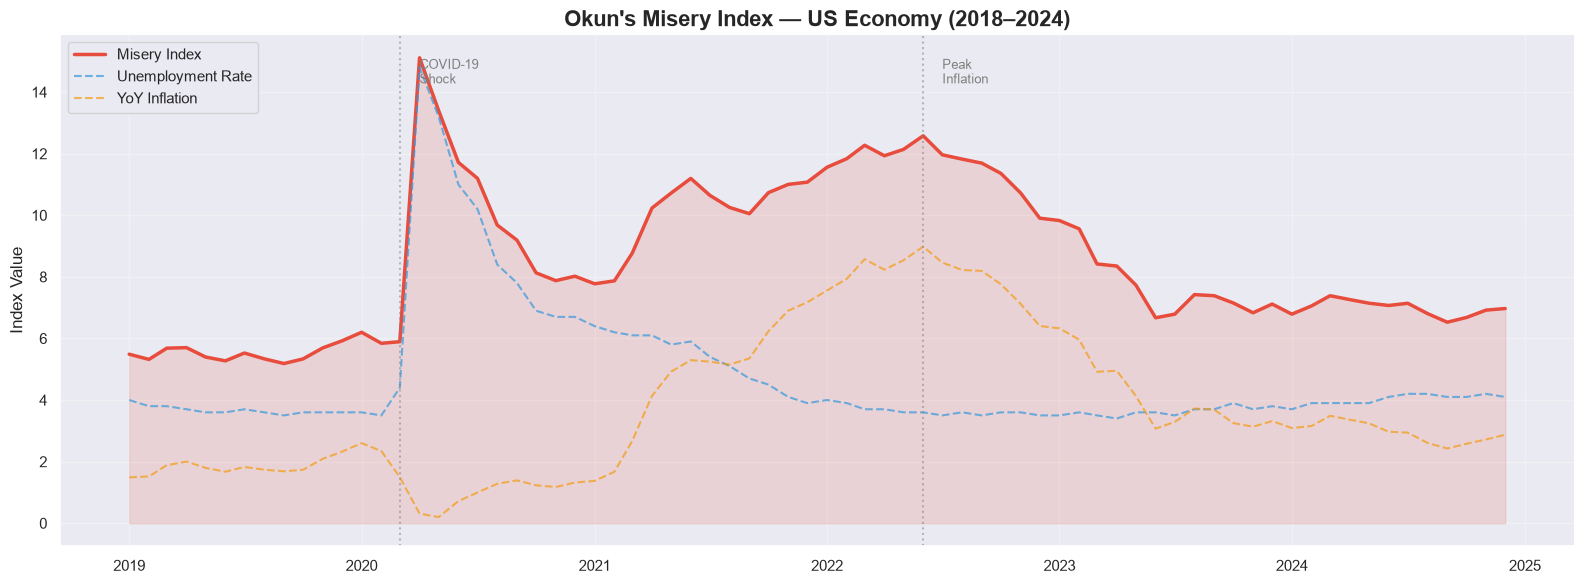

In [8]:
# Plot the Misery Index with key events annotated
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(misery_df["date"], misery_df["misery_index"], linewidth=2.5, color="#e74c3c", label="Misery Index")
ax.fill_between(misery_df["date"], misery_df["misery_index"], alpha=0.15, color="#e74c3c")

# Component breakdown
ax.plot(misery_df["date"], misery_df["unemployment_rate"], "--", linewidth=1.5, color="#3498db", alpha=0.7, label="Unemployment Rate")
ax.plot(misery_df["date"], misery_df["yoy_inflation"], "--", linewidth=1.5, color="#f39c12", alpha=0.7, label="YoY Inflation")

# Annotate key events
ax.axvline(pd.Timestamp("2020-03-01"), color="gray", linestyle=":", alpha=0.5)
ax.text(pd.Timestamp("2020-04-01"), ax.get_ylim()[1] * 0.9, "COVID-19\nShock", fontsize=9, color="gray")

ax.axvline(pd.Timestamp("2022-06-01"), color="gray", linestyle=":", alpha=0.5)
ax.text(pd.Timestamp("2022-07-01"), ax.get_ylim()[1] * 0.9, "Peak\nInflation", fontsize=9, color="gray")

ax.set_title("Okun's Misery Index — US Economy (2018–2024)", fontsize=16, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Index Value", fontsize=12)
ax.legend(loc="upper left", fontsize=11)
ax.grid(True, alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

### 1.3 Genius Lyrics

We fetch full lyric sheets for every unique track in our chart data.
The Genius API is rate-limited, so this step caches results to disk
and uses a 1.5-second delay between requests.

> ⏱️ **First run warning**: Fetching lyrics for ~2,000+ unique tracks takes
> approximately 1-2 hours due to rate limiting. Results are cached in
> `data/raw/lyrics_cache/` so subsequent runs are instant.

In [9]:
# Get unique tracks for lyrics fetching
unique_tracks = get_unique_tracks(charts_df)
print(f"🎤 Unique tracks to fetch lyrics for: {len(unique_tracks)}")
display(unique_tracks.head(10))

# Fetch lyrics (cached — only hits API for uncached tracks)
# ⚠️ SLOW on first run (~1.5s per track). Comment this cell if you want to skip lyrics.
lyrics_df_path = DATA_PROCESSED / "tracks_with_lyrics.csv"

if lyrics_df_path.exists():
    print("⏳ Loading pre-compiled tracks with lyrics from disk...")
    tracks_with_lyrics = pd.read_csv(lyrics_df_path)
    # Ensure NaN/missing lyrics are represented as None/object for processing
    tracks_with_lyrics["lyrics"] = tracks_with_lyrics["lyrics"].where(tracks_with_lyrics["lyrics"].notna(), None)
else:
    tracks_with_lyrics = fetch_lyrics_batch(unique_tracks)
    # Save the dataframe for quick loading next time
    tracks_with_lyrics.to_csv(lyrics_df_path, index=False)
    print(f"💾 Saved compiled tracks with lyrics to: {lyrics_df_path}")

lyrics_found = tracks_with_lyrics["lyrics"].notna().sum()
print(f"\n✅ Lyrics found: {lyrics_found} / {len(tracks_with_lyrics)} ({100*lyrics_found/len(tracks_with_lyrics):.1f}%)")

# Preview a sample
sample = tracks_with_lyrics[tracks_with_lyrics["lyrics"].notna()].head(3)
for _, row in sample.iterrows():
    print(f"\n🎵 {row['title']} — {row['artist']}")
    print(f"   {row['lyrics'][:200]}...")

cmi.ingest.spotify_charts | Unique tracks: 2136


🎤 Unique tracks to fetch lyrics for: 2136


,track_id,title,artist,danceability,energy,valence,acousticness,tempo,speechiness,instrumentalness
0,003eoIwxETJujVWmNFMoZy,Growing Pains,Alessia Cara,0.353,0.755,0.437,0.0822,191.153,0.7330,0.000000
1,00B7TZ0Xawar6NZ00JFomN,Best Life,Cardi B Featuring Chance The Rapper,0.620,0.625,0.665,0.2870,167.911,0.5530,0.000000
2,00ko9WaS4jOX1kEk3gvHjf,Hot Shower,Chance The Rapper Featuring MadeinTYO & DaBaby,0.897,0.522,0.623,0.0016,149.986,0.3740,0.000000
3,017PF4Q3l4DBUiWoXk4OWT,Break My Heart,Dua Lipa,0.730,0.729,0.467,0.1670,113.013,0.0883,0.000001
4,01FvQEvHETjWqcDpQDJdTb,Your Bartender,Morgan Wallen,0.555,0.771,0.442,0.2470,139.971,0.0282,0.000073
5,01TnVDiet1DFTsyWKUKovl,Numb,XXXTENTACION,0.414,0.416,0.196,0.1000,159.910,0.0251,0.179000
6,01jIO8SJFnpSiNLH1JaBZ5,You,Jacquees,0.735,0.453,0.335,0.4130,115.002,0.0602,0.000000
7,01z2fBGB8Hl3Jd3zXe4IXR,Come Back To Earth,Mac Miller,0.272,0.238,0.119,0.8900,83.507,0.0349,0.009250
8,02FaKXXL7KUtRc7K0k54tL,Cozy Little Christmas,Katy Perry,0.774,0.608,0.560,0.1280,137.494,0.1280,0.000000
9,03B2SfXuvDh1m9F4tqrX07,Skin,Sabrina Carpenter,0.557,0.457,0.328,0.4280,105.918,0.0335,0.000000


### 1.4 Raw Audio Complexity Feature Engineering (Spotify API)

We tap into the raw audio analysis endpoint to fetch chroma (pitch) and timbre
vectors. We calculate:
- **Harmonic Entropy**: a measure of chord complexity and predictability.
- **Timbral Variance**: standard deviation of timbre coefficients over time (roughness/compression).

If no Spotify credentials are set in `.env`, it defaults to offline fallback baselines.

In [12]:
from cmi.features.audio_analysis import fetch_audio_complexity_batch

complexity_df = fetch_audio_complexity_batch(unique_tracks)
print(f"\n✅ Audio complexity features calculated: {complexity_df.shape}")
display(complexity_df.head(10))

# Merge complexity features back into unique_tracks and tracks_with_lyrics
unique_tracks = unique_tracks.merge(complexity_df, on="track_id", how="left")
tracks_with_lyrics = tracks_with_lyrics.merge(complexity_df, on="track_id", how="left")

Fetching lyrics:  10%|█         | 221/2136 [05:33<48:09,  1.51s/it]lyricsgenius.genius | Searching for "Almost Maybes" by Jordan Davis...
lyricsgenius.genius | Done.
Fetching lyrics:  10%|█         | 222/2136 [05:36<1:05:43,  2.06s/it]lyricsgenius.genius | Searching for "KEKE" by 6ix9ine, Fetty Wap & A Boogie Wit da Hoodie...
lyricsgenius.genius | Done.
Fetching lyrics:  10%|█         | 223/2136 [05:41<1:33:16,  2.93s/it]lyricsgenius.genius | Searching for "Leave Me Alone" by Flipp Dinero...
lyricsgenius.genius | Done.
Fetching lyrics:  10%|█         | 224/2136 [05:45<1:49:07,  3.42s/it]lyricsgenius.genius | Searching for "Throat Baby (Go Baby)" by BRS Kash...
lyricsgenius.genius | Done.
Fetching lyrics:  11%|█         | 225/2136 [05:49<1:54:35,  3.60s/it]lyricsgenius.genius | Searching for "La Toxica" by Farruko...
lyricsgenius.genius | Done.
Fetching lyrics:  11%|█         | 226/2136 [05:52<1:47:35,  3.38s/it]lyricsgenius.genius | Searching for "The Voice" by Lil Durk...
lyricsgenius


✅ Lyrics found: 2111 / 2136 (98.8%)

🎵 Growing Pains — Alessia Cara
   You're on your own, kid
You are

Make my way through the motions, I try to ignore it
But home's looking farther the closer I get
Don't know why I can't see the end
Is it over yet? Hmm
A short leash an...

🎵 Best Life — Cardi B Featuring Chance The Rapper
   I'm livin' my best life, yeah, yeah
I'm livin' my best life (Best life)
Made a couple M's, you know (Ah! Huh!)

Said I'm livin' my best life
Said I'm livin' my best life
Made a couple M's with my best...

🎵 Hot Shower — Chance The Rapper Featuring MadeinTYO & DaBaby
   HIGHEST IN THE ROOM - Travis Scott
Bandit - Juice WRLD and YoungBoy Never Broke Again
Camelot - NLE Choppa
VIBEZ - DaBaby
223's - YNW Melly and 9lokknine
Hot - Young Thug and Gunna
BOP - DaBaby
F.N - ...


---
## 2. Feature Engineering — Multimodal Fusion

This is where the magic happens. We combine two fundamentally different
representations of each song:

1. **Audio features** (7D): What it *sounds* like — tempo, energy, valence, etc.
2. **Lyric embeddings** (768D → 10D): What it *says* — dense semantic vectors

The challenge: raw 768D embeddings would dominate the 7 audio features in any
distance metric. We use **UMAP** to compress lyrics to ~10 dimensions, preserving
macro themes (isolation vs. partying vs. heartbreak) without overwhelming the audio.

### 2.1 Lyric Embedding via Google Gemini

In [ ]:
# Filter to tracks that have lyrics
tracks_with_text = tracks_with_lyrics[tracks_with_lyrics["lyrics"].notna()].copy()
lyrics_list = tracks_with_text["lyrics"].tolist()

embeddings_cache_path = DATA_PROCESSED / "lyric_embeddings.npy"

if embeddings_cache_path.exists():
    print("⏳ Loading cached lyric embeddings from disk...")
    lyric_embeddings = np.load(embeddings_cache_path)
    if len(lyric_embeddings) != len(lyrics_list):
        print(f"⚠️ Cache mismatch: expected {len(lyrics_list)} embeddings, found {len(lyric_embeddings)}. Re-embedding...")
        lyric_embeddings = embed_lyrics(lyrics_list)
        np.save(embeddings_cache_path, lyric_embeddings)
else:
    print(f"📝 Embedding {len(lyrics_list)} lyric texts via gemini-embedding-001...")
    lyric_embeddings = embed_lyrics(lyrics_list)
    np.save(embeddings_cache_path, lyric_embeddings)

print(f"   Embedding matrix: {lyric_embeddings.shape}")

### 2.2 Dimensionality Reduction (UMAP)

In [ ]:
# UMAP: 768D → 10D
reduced_lyrics = reduce_embeddings(lyric_embeddings, n_components=EMBEDDING_DIM_TARGET)
print(f"📉 Reduced lyrics: {reduced_lyrics.shape}")

# Visualize the 2D UMAP projection for intuition
umap_2d = reduce_embeddings(lyric_embeddings, n_components=2)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    umap_2d[:, 0], umap_2d[:, 1],
    c=tracks_with_text["valence"].values if "valence" in tracks_with_text.columns else "steelblue",
    cmap="RdYlGn", alpha=0.6, s=15,
)
ax.set_title("2D UMAP of Lyric Embeddings\n(colored by Valence: Red=Sad, Green=Happy)", fontsize=14, fontweight="bold")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.colorbar(scatter, label="Valence", ax=ax)
plt.tight_layout()
plt.show()

### 2.3 Audio Feature Extraction & Fusion

In [ ]:
# Extract and scale audio features for tracks WITH lyrics
audio_matrix = extract_audio_matrix(tracks_with_text)
print(f"🔊 Audio matrix: {audio_matrix.shape}")

# Fuse: audio (7D) + reduced lyrics (10D) → 17D, StandardScaled
fused_matrix, fused_scaler = fuse_features(audio_matrix, reduced_lyrics)
print(f"🔗 Fused matrix: {fused_matrix.shape}")
print(f"   Feature dimensions: {audio_matrix.shape[1]} audio + {reduced_lyrics.shape[1]} lyric = {fused_matrix.shape[1]} total")

---
## 3. Temporal Clustering — Tracking Vibe Archetypes Over Time

Instead of clustering all songs at once (which would hide temporal dynamics),
we cluster within **monthly time windows** and use the **Hungarian Algorithm**
to maintain consistent cluster identities across months.

The label-switching problem: K-Means assigns arbitrary labels each run.
"High-Energy Melancholic Pop" might be Cluster 2 in January but Cluster 5
in February. The Hungarian algorithm finds the optimal 1-to-1 mapping between
old and new centroids based on Euclidean distance.

### 3.1 Optimal K Selection

In [ ]:
# Elbow plot + silhouette analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

elbow_plot(fused_matrix, k_range=range(2, 12), ax=ax1)
_, sil_scores = silhouette_analysis(fused_matrix, k_range=range(2, 12), ax=ax2)

plt.suptitle("Cluster Count Diagnostics", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

best_k = max(sil_scores, key=sil_scores.get)
print(f"\n🏆 Best K by silhouette score: {best_k} (score: {sil_scores[best_k]:.4f})")
print(f"   Using K={K_CLUSTERS} as specified in config")

### 3.2 Temporal Clustering with Hungarian Alignment

In [ ]:
# We need month labels aligned to the fused matrix
# The fused matrix corresponds to tracks_with_text (tracks that have lyrics)
month_labels = tracks_with_text["year_month"].values if "year_month" in tracks_with_text.columns else None

# If we don't have year_month from the unique tracks, derive it from charts_df
# This maps each track to its most common month
if month_labels is None or len(month_labels) != len(fused_matrix):
    # Use the chart date for temporal windowing
    # For unique tracks, assign the month of their peak chart position
    if "date" in tracks_with_text.columns:
        month_labels = pd.to_datetime(tracks_with_text["date"]).dt.to_period("M").values
    else:
        # Fallback: generate monthly labels from charts_df
        print("⚠️ No date column in unique tracks — using charts_df for temporal mapping")
        # Create a mapping of track → most common month
        id_col = "track_id" if "track_id" in charts_df.columns else "title"
        track_months = charts_df.groupby(id_col)["year_month"].first()
        month_labels = tracks_with_text[id_col].map(track_months).values

print(f"📅 Month labels: {len(month_labels)} entries, {pd.Series(month_labels).nunique()} unique months")

In [ ]:
# Run temporal clustering
streams = tracks_with_text["streams"].values if "streams" in tracks_with_text.columns else None

timeline = cluster_temporal_windows(
    fused_matrix=fused_matrix,
    months=month_labels,
    k=K_CLUSTERS,
    streams=streams,
)

print(f"\n✅ Temporal clustering complete:")
print(f"   Months tracked: {len(timeline.centroids_by_month)}")
print(f"   Label distribution: {pd.Series(timeline.labels).value_counts().to_dict()}")

In [ ]:
# Cluster stability analysis
stability = cluster_stability_score(timeline)
print("📊 Cluster Stability (lower drift = more stable identity):")
display(stability)

### 3.3 Cluster Evolution Visualization

In [ ]:
# Volumetric shares over time — the core visualization
if timeline.volumetric_shares is not None:
    shares = timeline.volumetric_shares.copy()

    # Plotly area chart for interactive exploration
    fig = go.Figure()

    colors = px.colors.qualitative.Set2[:K_CLUSTERS]
    for i, col in enumerate(shares.columns):
        fig.add_trace(go.Scatter(
            x=shares.index.astype(str),
            y=shares[col],
            mode="lines",
            name=col.replace("cluster_", "Cluster "),
            stackgroup="one",
            line=dict(width=0.5),
            fillcolor=colors[i % len(colors)],
        ))

    fig.update_layout(
        title="Cluster Volumetric Shares Over Time (% of Top 200 Streams)",
        xaxis_title="Month",
        yaxis_title="Share (%)",
        template="plotly_dark",
        height=500,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    )
    fig.show()

In [ ]:
# Centroid drift over time — how fast are cluster identities changing?
if timeline.drift_velocities:
    drift_df = pd.DataFrame(timeline.drift_velocities).T
    drift_df.columns = [f"Cluster {i}" for i in range(drift_df.shape[1])]

    fig = px.line(
        drift_df,
        title="Centroid Drift Velocity — How Fast Are 'Vibes' Shifting?",
        labels={"value": "Euclidean Drift", "index": "Month"},
        template="plotly_dark",
        height=400,
    )
    fig.show()

---
## 4. Econometric Analysis — Music vs. The Economy

Now we have stable clusters tracked over time. The key question:
**Do certain musical "vibes" expand or contract in response to economic stress?**

We test this with:
- **Rolling Pearson/Spearman Correlation** — ongoing relationship strength
- **Granger Causality** — does economic pain *precede* music shifts?

### 4.1 Merge Cluster Dynamics with Misery Index

In [ ]:
# Get cluster volumetric shares as a time series
cluster_shares = compute_volumetric_shares(timeline)
print(f"📊 Cluster shares: {cluster_shares.shape}")
display(cluster_shares.head())

In [ ]:
# Static (overall) correlation between each cluster and the Misery Index
static_corr = static_correlation(cluster_shares, misery_df)
print("\n📐 Static Correlations (Cluster Share vs. Misery Index):")
display(static_corr)

In [ ]:
# Classify clusters by economic sensitivity
classified = classify_clusters(static_corr)
print("\n🏷️ Cluster Economic Sensitivity Classification:")
display(classified[["cluster", "pearson_r", "economic_sensitivity"]])

### 4.2 Rolling Correlation — How the Relationship Evolves

In [ ]:
# Rolling correlation (6-month window)
rolling_corr = rolling_correlation(cluster_shares, misery_df, window=6)

fig = px.line(
    rolling_corr,
    title="Rolling 6-Month Correlation: Cluster Shares vs. Misery Index",
    labels={"value": "Pearson r", "index": "Month"},
    template="plotly_dark",
    height=450,
)
fig.add_hline(y=0, line_dash="dash", line_color="white", opacity=0.3)
fig.add_hline(y=0.5, line_dash="dot", line_color="green", opacity=0.3)
fig.add_hline(y=-0.5, line_dash="dot", line_color="red", opacity=0.3)
fig.show()

### 4.3 Granger Causality — Does Economic Pain Predict Music Shifts?

In [ ]:
# Granger causality test (up to 3-month lag)
granger_results = granger_causality(cluster_shares, misery_df, max_lag=3)
print("🔬 Granger Causality Results (p < 0.05 = significant):")
display(granger_results)

# Highlight significant results
significant = granger_results[granger_results["p_value"] < 0.05]
if len(significant) > 0:
    print(f"\n🎯 Significant Granger-causal relationships found:")
    for _, row in significant.iterrows():
        print(f"   Misery Index → {row['cluster']} (lag={row['lag']}, p={row['p_value']:.4f})")
else:
    print("\n   No significant Granger-causal relationships at p < 0.05")

### 4.4 The Cultural Misery Index Dashboard

In [ ]:
# Overlay: Cluster shares + Misery Index on the same timeline
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    subplot_titles=("Cluster Volumetric Shares (%)", "Misery Index"),
    row_heights=[0.65, 0.35],
)

# Top panel: stacked cluster shares
colors = px.colors.qualitative.Set2[:K_CLUSTERS]
for i, col in enumerate(cluster_shares.columns):
    fig.add_trace(
        go.Scatter(
            x=cluster_shares.index,
            y=cluster_shares[col],
            name=col.replace("cluster_", "Cluster "),
            stackgroup="one",
            line=dict(width=0.5),
            fillcolor=colors[i % len(colors)],
        ),
        row=1, col=1,
    )

# Bottom panel: Misery Index
fig.add_trace(
    go.Scatter(
        x=misery_df["date"],
        y=misery_df["misery_index"],
        name="Misery Index",
        line=dict(color="#e74c3c", width=2.5),
        fill="tozeroy",
        fillcolor="rgba(231, 76, 60, 0.15)",
    ),
    row=2, col=1,
)

fig.update_layout(
    title="🎵 The Cultural Misery Index Dashboard",
    template="plotly_dark",
    height=700,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
    showlegend=True,
)
fig.show()

---
## 5. GenAI Narrative Engine — The Story Behind the Data

Instead of just plotting charts, we generate a structured data payload for each
cluster and prompt **Gemini 3.5 Flash** to write the cultural digest.

The LLM acts as an "economic sociologist and cultural critic," interpreting
what the sonic and semantic properties tell us about consumer coping mechanisms.

### 5.1 Build Cluster Payloads

In [ ]:
# Build payloads for each cluster during key economic periods
payloads = []

# Identify key periods from the Misery Index
# (we'll pick the highest and lowest misery periods for contrast)
misery_df_sorted = misery_df.sort_values("misery_index", ascending=False)
high_misery_period = misery_df_sorted.head(6)  # Top 6 months of economic stress
low_misery_period = misery_df_sorted.tail(6)   # Bottom 6 months of economic calm

print("📊 High-stress economic periods:")
display(high_misery_period[["date", "misery_index", "unemployment_rate", "yoy_inflation"]])

print("\n📊 Low-stress economic periods:")
display(low_misery_period[["date", "misery_index", "unemployment_rate", "yoy_inflation"]])

In [ ]:
# Build a payload for each cluster
for cluster_id in range(K_CLUSTERS):
    # Get data for this cluster
    mask = timeline.labels == cluster_id
    cluster_data = tracks_with_text[mask].copy() if sum(mask) > 0 else pd.DataFrame()

    if len(cluster_data) == 0:
        continue

    # Get centroid (from the last available month)
    last_month = sorted(timeline.centroids_by_month.keys())[-1]
    centroids = timeline.centroids_by_month[last_month]
    centroid = centroids[cluster_id] if cluster_id < len(centroids) else np.zeros(fused_matrix.shape[1])

    # Get correlation
    cluster_col = f"cluster_{cluster_id}"
    corr_row = static_corr[static_corr["cluster"] == cluster_col]
    corr_val = corr_row["pearson_r"].values[0] if len(corr_row) > 0 else 0.0

    # Volume share delta
    if timeline.volumetric_shares is not None:
        shares = timeline.volumetric_shares[cluster_col]
        if len(shares) > 1:
            first_half = shares.iloc[:len(shares)//2].mean()
            second_half = shares.iloc[len(shares)//2:].mean()
            delta = second_half - first_half
            delta_str = f"{'+' if delta > 0 else ''}{delta:.1f}% shift (early → late period)"
        else:
            delta_str = "Insufficient data"
    else:
        delta_str = "No volumetric data"

    payload = build_cluster_payload(
        cluster_id=cluster_id,
        cluster_data=cluster_data,
        centroid=centroid,
        temporal_window=f"{DATE_START[:4]}–{DATE_END[:4]} (Full Period)",
        misery_correlation=corr_val,
        volume_share_delta=delta_str,
    )
    payloads.append(payload)

print(f"📦 Built {len(payloads)} cluster payloads")

# Preview one
import json
print("\nSample payload:")
print(json.dumps(payloads[0], indent=2))

### 5.2 Generate Cultural Narratives

In [ ]:
# Generate the full Cultural Misery Index report
print("🤖 Generating narratives via Gemini 3.5 Flash...\n")
report = generate_full_report(payloads)

# Display the report as rendered markdown
display(Markdown(report))

In [ ]:
# Save the report to disk
report_path = DATA_PROCESSED / "cultural_misery_index_report.md"
report_path.write_text(report)
print(f"💾 Report saved to: {report_path}")

---
## 6. Key Findings & Interpretation

The Cultural Misery Index reveals how music acts as a collective emotional
barometer. Key patterns to look for:

- **Reactive clusters** (positive Misery correlation): These "vibes" expand
  when people are stressed — potentially serving as escapism or emotional processing

- **Counter-cyclical clusters** (negative Misery correlation): These contract
  during stress — perhaps too frivolous or optimistic for hard times

- **Stable clusters** (low correlation): Enduring musical archetypes that
  persist regardless of economic conditions

- **The COVID Signature**: The 2020 unemployment spike should produce a
  visible discontinuity in cluster dynamics — look for rapid shifts in
  the dashboard around March–June 2020

- **The Inflation Wave**: 2021–2022 saw sustained economic anxiety — does
  this correlate with a gradual drift in dominant clusters?

In [ ]:
# Final summary table
print("📋 Cluster Summary:")
summary_rows = []
for payload in payloads:
    row = {
        "Cluster": payload["cluster_id"],
        "Tracks": payload["n_tracks"],
        "Misery Correlation": payload["economic_metrics"]["misery_index_correlation"],
        "Volume Delta": payload["economic_metrics"]["volume_share_delta"],
        "Top Keywords": ", ".join(payload.get("top_lyric_keywords", [])[:5]),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("\n🎵 The Cultural Misery Index analysis is complete.")
print("   Run the notebook from top to bottom to reproduce all results.")